# Group Work Project #2 - Part2 - Behavioural Data: News Data

We choose news data as the alternative data subcategory as it is timely, widely accessible and easily available for use in academic and research settings. News platforms generate a continuous stream of professionally curated content, making this data particularly valuable for capturing real time narratives and public reactions to evolving market conditions.

The speed at which information is reported and broadcasted allows researchers to analyze sentiment, attention and behavioral responses almost instantaneously, offering insights that traditional data sources often capture with significant delays.

# **1. Sources of data**

There are many different news platforms, each operating under established editorial standards and journalistic practices. While the core objective across these platforms is to report factual information, differences in coverage focus, geography, and publication style can influence how economic and financial events are reported and prioritized.

Some well known financial news sources include Reuters, Bloomberg, Financial Times and The Wall Street Journal which focus primarily on economic, financial, and market related reporting. These platforms play an important role in shaping market expectations by rapidly disseminating information on macroeconomic indicators, corporate announcements, and geopolitical developments.

News data can be accessed through multiple sources. Many providers offer APIs that allow structured access to headlines, articles, and associated metadata, such as NewsAPI and GDELT. When API access is limited, web scraping techniques using tools like BeautifulSoup or Selenium may also be employed subject to ethical and legal considerations.

# **2. Types of data**







One of the advantages of Alternate data over traditional data is the heterogeneity of the data. Traditional data are usually strutured,organized and formatted while alternative data encompasses not only structured but also semi struuctured and unstructured data like pictures,videos and texts.
The heterogeneity of alternative data reduces the possibility of manipulation allowing them to exhibit real economic conditions more accurately.



*   Textual Content: Headlines,article body text,summaries or descriptions.
This data is primarily used for Sentiment Analysis,Topic Modelling,Keyword Extracction,etc.
*   Metadata: Publication date and time,Source or publisher,Journalist,Article Category.This data is primarily used for Time Series Analysis, Source level Comparison,etc.
*   Temporal Data: Publication timestamps, Frequency of article over time which is primarily used for Studying information flow,Linking news to market movements,etc.



# **3. Quality of Data**

Like most other forms of alternative data, news data is highly prone to noise and quality related issues. Since it is largely unstructured, it often includes irrelevant details, ambiguous language, or low information content.
In addition to this, the credibility of the news source itself is crucial. Not all platforms follow the same editorial standards, and some sources may be biased, sensationalized, or factually unreliable. Blindly accepting information without considering the reputation and trustworthiness of the publisher can introduce serious errors into analysis. As a result, evaluating source credibility along with proper filtering and preprocessing is an important step when working with news data.




*   Noise : News data contains a large amount of irrelevant or repetitive information, such as opinion pieces and sensational headlines. This noise can mask meaningful financial signals and lead to misleading trends.
*   Sampling Bias : News coverage is uneven across time, regions and firms. This imbalance can distort trend analysis and exaggerate perceived market activity.
*  Language and Context: Financial news uses nuanced and context dependent language that can be misinterpreted. Words or phrases can appear positive or negative without reflecting actual market sentiment.

# **4. Ethical Issues**

*   Consent and Licensing: News data usage must comply with publisher licenses, copyrights.
*   Bias and Harm: Uneven or biased news coverage can reinforce existing narratives and lead to unfair market or societal impacts
*   Manipulation Risks: Large-scale analysis of news can be misused to influence markets, public opinion, or amplify misinformation.

# **5. Python Code to Import Data and Structure into useful data structure**

Bloomberg data was used for the financial analysis and was accessed through a freely available dataset on Hugging Face. Bloomberg was selected as the primary news source due to its credibility, consistency, and focus on financial and macroeconomic reporting.

In [66]:
import pandas as pd
df2 = pd.read_parquet("hf://datasets/tylu0117/Bloomberg_Financial_News/bloomberg_financial_data.parquet.gzip")

In [67]:
print(df2.head())

                                            Headline        Journalists  \
0  Ivory Coast Keeps Cocoa Export Tax Below 22%, ...  [Baudelaire Mieu]   
1  USDA Boxed Beef Cutout Closing Prices for Octo...   [Michael Carone]   
2         U.S. September Small Business Jobs Summary       [Alex Tanzi]   
3  Greece’s GSEE Says Won’t Meet For Talks With T...    [Natalie Weeks]   
4  Clean-Tech Companies Should Get 10-Year Tax Br...         [Ari Levy]   

                 Date                                               Link  \
0 2011-10-06 15:14:20  http://www.bloomberg.com/news/2011-10-06/ivory...   
1 2011-10-06 20:22:42  http://www.bloomberg.com/news/2011-10-06/usda-...   
2 2011-10-06 19:00:00  http://www.bloomberg.com/news/2011-10-06/u-s-s...   
3 2011-10-06 14:45:34  http://www.bloomberg.com/news/2011-10-06/greec...   
4 2011-10-06 18:34:41  http://www.bloomberg.com/news/2011-10-06/clean...   

                                             Article  
0  Export taxes on cocoa beans from I

In [68]:
df2.describe()

,Date
count,446762
mean,2012-02-24 23:29:27.512098048
min,2006-10-20 20:16:16
25%,2011-05-27 09:56:44.750000128
50%,2012-02-17 20:06:48.500000
75%,2012-12-11 17:10:33.750000128
max,2013-11-26 04:51:52


In [69]:
df2.shape

(446762, 5)

In [70]:
df_sample = df2.sample(30000, random_state=42)

In [71]:
df_sample['Date'] = pd.to_datetime(df_sample['Date']).dt.date

Market data from yfinance is available at a daily level. To align with this news data timestamps were converted to dates. Working at the daily level avoids unnecessary precision reduces noise from intraday timing differences and better matches how markets typically react to news, often in the next trading session.
Using full timestamp level news would also add complexity without offering meaningful improvements given the daily nature of the market data.

In [72]:
### removing Columns that is of no use in our analysis and to reduce the time and space complexity of our code
df_sample = df_sample.drop(columns=['Link'])

In [73]:
df_sample['Headline'] = df_sample['Headline'].fillna('')
df_sample['Article'] = df_sample['Article'].fillna('')

In [74]:
df_sample['headline_length'] = df_sample['Headline'].str.len()   ###number of chars in the headline
df_sample['article_length'] = df_sample['Article'].str.len()      ###number of chars in the Article
df_sample['word_count'] = df_sample['Article'].str.count(r'\w+')   ### number of words in the Article
print(df_sample.head())

                                                 Headline  \
299017  Indonesia Stock Movers: Energi Mega, Greenwood...   
6506    Five Ways Japan Could Get Creative on Deflatio...   
277750  Aegon to Sell Shares to Repay State Aid After ...   
116038  Mickelson’s Run at Fourth Masters Title Is Der...   
224047  ZEN VOCE CORP May Sales Rise 0.00% (Table) : 3...   

                       Journalists        Date  \
299017  [Femi Adi, Berni Moestafa]  2011-12-23   
6506               [William Pesek]  2011-08-03   
277750              [Maudvan Gaal]  2011-02-24   
116038          [Erik Matuszewski]  2012-04-09   
224047                 [Janet Ong]  2012-06-08   

                                                  Article  headline_length  \
299017  Shares of the following companies had unusual ...               62   
6506    It's kitchen-sink time in Tokyo. Until now, Ja...               59   
277750  Aegon NV , the Dutch owner of U.S. insurer Tra...               72   
116038  A risk-takin

In [75]:
from textblob import TextBlob
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

# English stopwords
stop_words = set(stopwords.words('english'))

## remove these words from the stopwords so that it remains in the text
negations = {"not", "no", "nor", "never", "n't"}
stop_words = stop_words - negations

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered)

text = "The company's performance is not very good but the outlook is improving"

clean_text = remove_stopwords(text)
print(clean_text)

df_sample['Headline'] = df_sample['Headline'].apply(remove_stopwords)
df_sample['Article'] = df_sample['Article'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


company's performance not good outlook improving


For financial data negation words are important so removing it from the stopword list will be beneficial and will give more accurate analysis.

In [76]:
##### We will use Textblob for the sentiment analysis of each article.
from textblob import TextBlob
df_sample['headline_sentiment'] = df_sample['Headline'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

df_sample['article_sentiment'] = df_sample['Article'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

The score is between -1 and 1 where 0 is for neutral tone, -1 for negative sentiment and +1 for positive sentiment

In [77]:
# print(df_sample.head())

In [78]:
import numpy as np

def extract_journalist(x):
    if isinstance(x, (list, np.ndarray)):
        return x[0] if len(x) > 0 else np.nan
    return x

df_sample['Journalists'] = df_sample['Journalists'].apply(extract_journalist)


In [79]:
df_sample.head()

,Headline,Journalists,Date,Article,headline_length,article_length,word_count,headline_sentiment,article_sentiment
299017,"Indonesia Stock Movers: Energi Mega, Greenwood...",Femi Adi,2011-12-23,Shares following companies unusual (JCI) moves...,62,2100,358,0.0,0.081019
6506,Five Ways Japan Could Get Creative Deflation: ...,William Pesek,2011-08-03,"kitchen-sink time Tokyo. now, Japan thrown eve...",59,2231,379,0.5,0.069704
277750,Aegon Sell Shares Repay State Aid Net Income B...,Maudvan Gaal,2011-02-24,"Aegon NV , Dutch owner U.S. insurer Transameri...",72,4245,730,0.0,0.019688
116038,Mickelson’s Run Fourth Masters Title Derailed ...,Erik Matuszewski,2012-04-09,risk-taking left-hander put ceremonial green j...,61,2396,450,0.0,0.044985
224047,ZEN VOCE CORP May Sales Rise 0.00% (Table) : 3...,Janet Ong,2012-06-08,ZEN VOCE CORP (3581) said unconsolidated sales...,52,511,63,0.0,0.368182


In [80]:
df_sample['articles_by_journalist'] = df_sample.groupby('Journalists')['Journalists'].transform('count')

In [81]:
df_sample['Date'] = pd.to_datetime(df_sample['Date'], errors='coerce')

# **6. Exploratory data analysis of sample data**

<Axes: title={'center': 'Daily News Volume'}, xlabel='Date'>

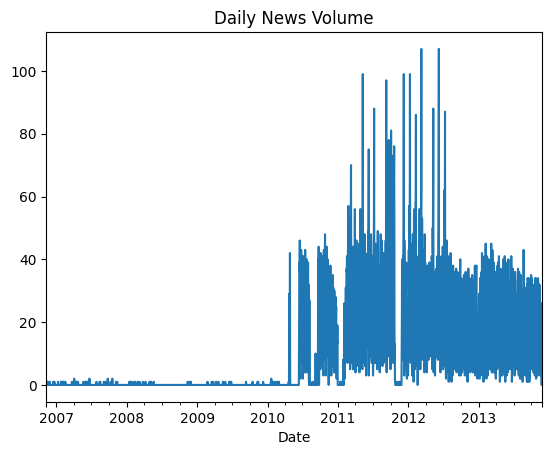

In [82]:
df_sample.set_index('Date').resample('D').size().plot(
    title="Daily News Volume"
)

**Data Quality issue** : The data seems to be not evenly distributed. It exhibits temporal imbalance with very few data points in earlier years and higher data availability in later periods.

In [83]:
df_sample['year'] = df_sample['Date'].dt.year
yearly_counts = df_sample.groupby('year').size()
print(yearly_counts)

year
2006       7
2007      35
2008      18
2009      16
2010    3937
2011    9427
2012    9547
2013    7013
dtype: int64


To ensure that the analysis is based on reliable and meaningful information, the study focuses on time periods with adequate and consistent news coverage.  A threshold of 3,000 articles provides a sufficiently large sample for aggregate measures to converge and reduces the impact of outliers in textual sentiment and keyword based features.

3000 articles/year ≈ 8 articles per day, which is the minimum for:

* meaningful daily counts
* rolling window analysis

In [84]:
valid_years = yearly_counts[yearly_counts > 3000].index

In [85]:
df_sample = df_sample[df_sample['year'].isin(valid_years)]

array([[<Axes: title={'center': 'headline_length'}>,
        <Axes: title={'center': 'article_length'}>]], dtype=object)

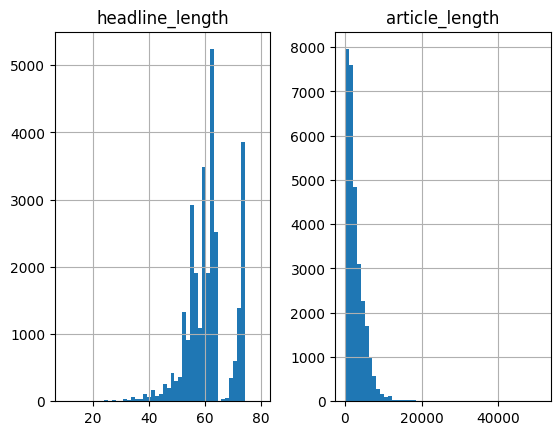

In [86]:
df_sample[['headline_length', 'article_length']].hist(bins=50)

<Axes: xlabel='word_count', ylabel='article_sentiment'>

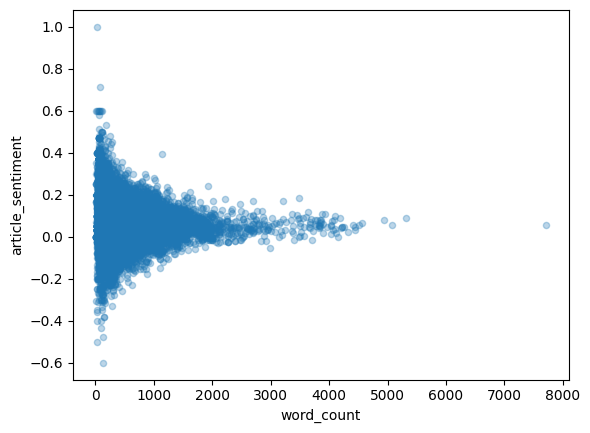

In [87]:
df_sample.plot.scatter(
    x='word_count',
    y='article_sentiment',
    alpha=0.3
)

The above plot shows that the short articles have extreme sentiment while the long articles shows more of a neutral sentiment.

In [88]:
(df_sample['headline_sentiment'] - df_sample['article_sentiment']).describe()

,0
count,29924.000000
mean,-0.058264
std,0.174530
min,-1.192605
25%,-0.125315
50%,-0.060457
75%,0.000000
max,1.062500


Half of the articles have:
Headlines that are noticeably more negative than the article text.
In at least 75% of cases, the headline sentiment is less than or equal to article sentiment.

Headlines tend to show stronger sentiment compared to the corresponding article body, mainly because they are designed to grab attention. This further suggests that headline sentiment alone cannot be used for analysis, as it may exaggerate the overall tone of the news. At the same time, headlines cannot be ignored, since they shape first impressions and often drive immediate reactions. Therefore, it makes sense to give more weight to article level sentiment while still considering headline sentiment as part of the analysis.

In [89]:
journalist_stats = df_sample.groupby('Journalists').agg({
    'article_sentiment': 'mean',
    'word_count': 'mean',
    'Headline': 'count'
}).rename(columns={'Headline': 'article_count'})


In [90]:
df_sample.head()

,Headline,Journalists,Date,Article,headline_length,article_length,word_count,headline_sentiment,article_sentiment,articles_by_journalist,year
299017,"Indonesia Stock Movers: Energi Mega, Greenwood...",Femi Adi,2011-12-23,Shares following companies unusual (JCI) moves...,62,2100,358,0.0,0.081019,5.0,2011
6506,Five Ways Japan Could Get Creative Deflation: ...,William Pesek,2011-08-03,"kitchen-sink time Tokyo. now, Japan thrown eve...",59,2231,379,0.5,0.069704,28.0,2011
277750,Aegon Sell Shares Repay State Aid Net Income B...,Maudvan Gaal,2011-02-24,"Aegon NV , Dutch owner U.S. insurer Transameri...",72,4245,730,0.0,0.019688,14.0,2011
116038,Mickelson’s Run Fourth Masters Title Derailed ...,Erik Matuszewski,2012-04-09,risk-taking left-hander put ceremonial green j...,61,2396,450,0.0,0.044985,157.0,2012
224047,ZEN VOCE CORP May Sales Rise 0.00% (Table) : 3...,Janet Ong,2012-06-08,ZEN VOCE CORP (3581) said unconsolidated sales...,52,511,63,0.0,0.368182,1232.0,2012


In [91]:
print(journalist_stats)

                                                    article_sentiment  \
Journalists                                                             
A.A.Gill                                                     0.038758   
A.Craig Copetas                                              0.097418   
A.Gary Shilling                                              0.009641   
A.J.Flick                                                    0.112121   
Aaron Clark                                                  0.011124   
...                                                               ...   
[bn:PRSN=16804050]Chris Spillane[]                           0.113731   
[bn:PRSN=1]Bob Bensch[]                                      0.034848   
[bn:PRSN=1]Eva Woo[].Editors:[bn:PRSN=1]John Liu[]           0.061538   
s                                                            0.040000   
the Editors                                                  0.060116   

                                                  

In [92]:
df_sample.groupby('Journalists')['headline_sentiment'].mean()

,headline_sentiment
Journalists,
A.A.Gill,0.800000
A.Craig Copetas,0.000000
A.Gary Shilling,0.000000
A.J.Flick,0.000000
Aaron Clark,-0.180839
...,...
[bn:PRSN=16804050]Chris Spillane[],0.000000
[bn:PRSN=1]Bob Bensch[],0.000000
[bn:PRSN=1]Eva Woo[].Editors:[bn:PRSN=1]John Liu[],0.000000


<Axes: >

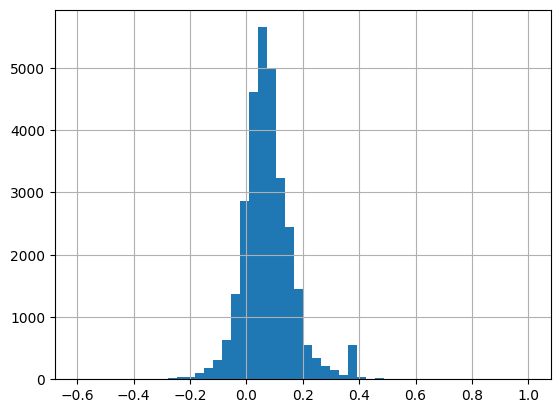

In [93]:
df_sample['article_sentiment'].hist(bins=50)

The sentiment distribution is centered around neutrality, consistent with professional journalistic standards.

In [94]:
df_sample['finance_related'] = df_sample['Article'].str.contains(
    'market|inflation|interest rate|stocks|economy|risk|growth|crisis',
    case=False
)

df_sample['finance_related'].value_counts(normalize=True)


,proportion
finance_related,
True,0.564229
False,0.435771


In [95]:
daily_news = df_sample.groupby(df_sample['Date'].dt.date).size()

In [96]:
print(daily_news)

Date
2010-01-18     1
2010-01-20     2
2010-01-28     1
2010-01-29     1
2010-02-04     1
              ..
2013-11-21    23
2013-11-22    26
2013-11-23     6
2013-11-25    14
2013-11-26     4
Length: 1174, dtype: int64


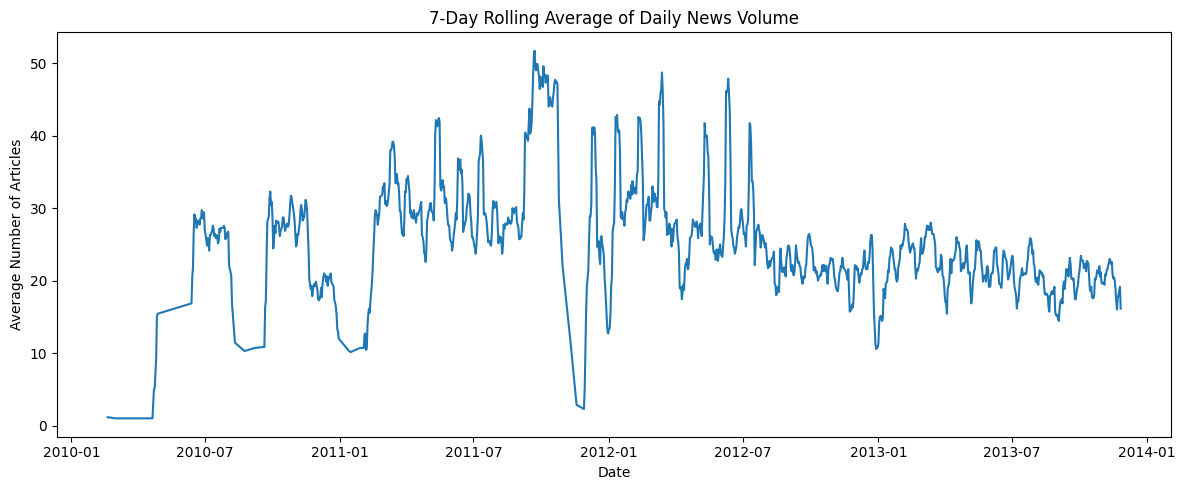

In [97]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
daily_news.rolling(7).mean().plot()
plt.title("7-Day Rolling Average of Daily News Volume")
plt.xlabel("Date")
plt.ylabel("Average Number of Articles")
plt.tight_layout()
plt.show()


In [98]:
from textblob import TextBlob

df_sample['headline_sentiment'] = df_sample['Headline'].apply(
    lambda x: TextBlob(x).sentiment.polarity if isinstance(x, str) else 0
)

In [99]:
df_sample.groupby(df_sample['Date'].dt.date)['headline_sentiment'].mean()

,headline_sentiment
Date,
2010-01-18,0.000000
2010-01-20,0.200000
2010-01-28,-0.125000
2010-01-29,-0.250000
2010-02-04,0.000000
...,...
2013-11-21,0.009783
2013-11-22,0.020629
2013-11-23,-0.116667


In [100]:
keywords = ['inflation', 'rate', 'recession', 'growth', 'crisis']

for k in keywords:
    df_sample[k] = df_sample['Article'].str.contains(k, case=False, na=False).astype(int)

In [101]:
df_sample.groupby('Journalists')['headline_sentiment'].mean()

,headline_sentiment
Journalists,
A.A.Gill,0.800000
A.Craig Copetas,0.000000
A.Gary Shilling,0.000000
A.J.Flick,0.000000
Aaron Clark,-0.180839
...,...
[bn:PRSN=16804050]Chris Spillane[],0.000000
[bn:PRSN=1]Bob Bensch[],0.000000
[bn:PRSN=1]Eva Woo[].Editors:[bn:PRSN=1]John Liu[],0.000000


In [102]:
risk_words = [
    'risk', 'uncertainty', 'fear', 'crisis', 'loss', 'decline', 'volatility',
    'instability', 'downturn', 'default', 'shock', 'bubble', 'panic',
    'recession', 'collapse', 'debt', 'inflation', 'deflation', 'bearish',
    'selloff', 'liquidity', 'contagion', 'downgrade', 'volatility', 'fraud'
]

def risk_count(text):
    if not isinstance(text, str):
        return 0
    text = text.lower()
    return sum(text.count(word) for word in risk_words)

# weights
ARTICLE_WEIGHT = 0.7
HEADLINE_WEIGHT = 0.3

sentiment_factor_headline = 1 + 0.5*(-df_sample['headline_sentiment'])
sentiment_factor_article = 1 + 0.5*(-df_sample['article_sentiment'])

df_sample['risk_score'] = (
    ARTICLE_WEIGHT *sentiment_factor_article* df_sample['Article'].apply(risk_count) +
    HEADLINE_WEIGHT *sentiment_factor_headline* df_sample['Headline'].apply(risk_count)
)


In [103]:
print(df_sample)

                                                 Headline       Journalists  \
299017  Indonesia Stock Movers: Energi Mega, Greenwood...          Femi Adi   
6506    Five Ways Japan Could Get Creative Deflation: ...     William Pesek   
277750  Aegon Sell Shares Repay State Aid Net Income B...      Maudvan Gaal   
116038  Mickelson’s Run Fourth Masters Title Derailed ...  Erik Matuszewski   
224047  ZEN VOCE CORP May Sales Rise 0.00% (Table) : 3...         Janet Ong   
...                                                   ...               ...   
195432  Lira Weakens 1st Day 4 Greek Elections Relief ...   Benjamin Harvey   
248932  BP Said Plan 60-Day Whiting Ultraformer Shutdo...       Aaron Clark   
192024                           NABARD CP's Issued:India  Shraddha Kothari   
257785  Germany Recommends Citizens Japan Consider Lea...    Takahiko Hyuga   
424123  Saudi Arabia’s Petrochemical Exports Advance 3...        Wael Mahdi   

             Date                                  

In [104]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from scipy.stats import zscore

# Compute z-score normalized risk score
df_sample['risk_score_z'] = zscore(df_sample['risk_score'])


# reshape for sklearn
scaler = MinMaxScaler(feature_range=(0,1))
df_sample['risk_score'] = scaler.fit_transform(df_sample['risk_score_z'].values.reshape(-1,1))

df_sample['risk_score'].min(), df_sample['risk_score'].max()

(0.0, 1.0)

In [105]:
# Quartiles: Q1, Q2, Q3
q1 = df_sample['risk_score'].quantile(0.25)
q2 = df_sample['risk_score'].quantile(0.50)  # median
q3 = df_sample['risk_score'].quantile(0.75)

print(f"Q1 (25%): {q1}")
print(f"Q2 (50% / median): {q2}")
print(f"Q3 (75%): {q3}")


Q1 (25%): 0.0
Q2 (50% / median): 0.009982084701730062
Q3 (75%): 0.030927432252182828


In [106]:
df_sample['risk_score'].describe()

,risk_score
count,29924.000000
mean,0.025765
std,0.045311
min,0.000000
25%,0.000000
50%,0.009982
75%,0.030927
max,1.000000


In [107]:
(df_sample['risk_score'] == 0).sum(), len(df_sample)

(np.int64(13223), 29924)

In [108]:
########## checking the risky articles only
df_sample[df_sample['risk_score'] > 0]['risk_score'].describe()

,risk_score
count,16701.000000
mean,0.046164
std,0.052315
min,0.002248
25%,0.010527
50%,0.029532
75%,0.059971
max,1.000000


In [109]:
############ Market dataframe

In [110]:
import yfinance as yf

In [111]:
start_dt=df_sample['Date'].min()
end_dt=df_sample['Date'].max()
print(start_dt)
print(end_dt)

2010-01-18 00:00:00
2013-11-26 00:00:00


In [112]:
sp500 = yf.download('^GSPC', start=start_dt, end=end_dt)
nifty = yf.download('^NSEI', start=start_dt, end=end_dt)

/tmp/ipython-input-686299955.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', start=start_dt, end=end_dt)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-686299955.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download('^NSEI', start=start_dt, end=end_dt)
[*********************100%***********************]  1 of 1 completed


In [113]:
sp500.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2010-01-19,1150.229980,1150.449951,1135.770020,1136.030029,4724830000
2010-01-20,1138.040039,1147.949951,1129.250000,1147.949951,4810560000
2010-01-21,1116.479980,1141.579956,1114.839966,1138.680054,6874290000
2010-01-22,1091.760010,1115.489990,1090.180054,1115.489990,6208650000
2010-01-25,1096.780029,1102.969971,1092.400024,1092.400024,4481390000


In [114]:
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2010-01-18,5274.850098,5292.500000,5228.950195,5253.649902,0
2010-01-19,5225.649902,5287.799805,5218.649902,5274.200195,0
2010-01-20,5221.700195,5256.700195,5201.399902,5226.100098,0
2010-01-21,5094.149902,5220.350098,5085.450195,5220.200195,0
2010-01-22,5036.000000,5094.149902,4954.850098,5094.149902,0


Date is here as the index, need to remove it from the index and keep it in the column

In [115]:
sp500.columns = sp500.columns.droplevel(1)
nifty.columns = nifty.columns.droplevel(1)
sp500 = sp500.reset_index()
nifty = nifty.reset_index()
print(sp500.columns.tolist())
print(nifty.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [116]:
df_sample['Date'] = pd.to_datetime(df_sample['Date'])
sp500['Date'] = pd.to_datetime(sp500['Date'])
nifty['Date'] = pd.to_datetime(nifty['Date'])

In [117]:
###Aggregate risk score by date
daily_risk = df_sample.groupby('Date')['risk_score'].mean()

In [118]:
merged = pd.merge(
    daily_risk,
    sp500[['Date', 'Close']],
    on='Date',
    how='inner'
)

In [119]:
print(merged.head())

        Date  risk_score        Close
0 2010-01-20    0.010140  1138.040039
1 2010-01-28    0.020347  1084.530029
2 2010-01-29    0.009886  1073.869995
3 2010-02-04    0.000000  1063.109985
4 2010-02-19    0.000000  1109.170044


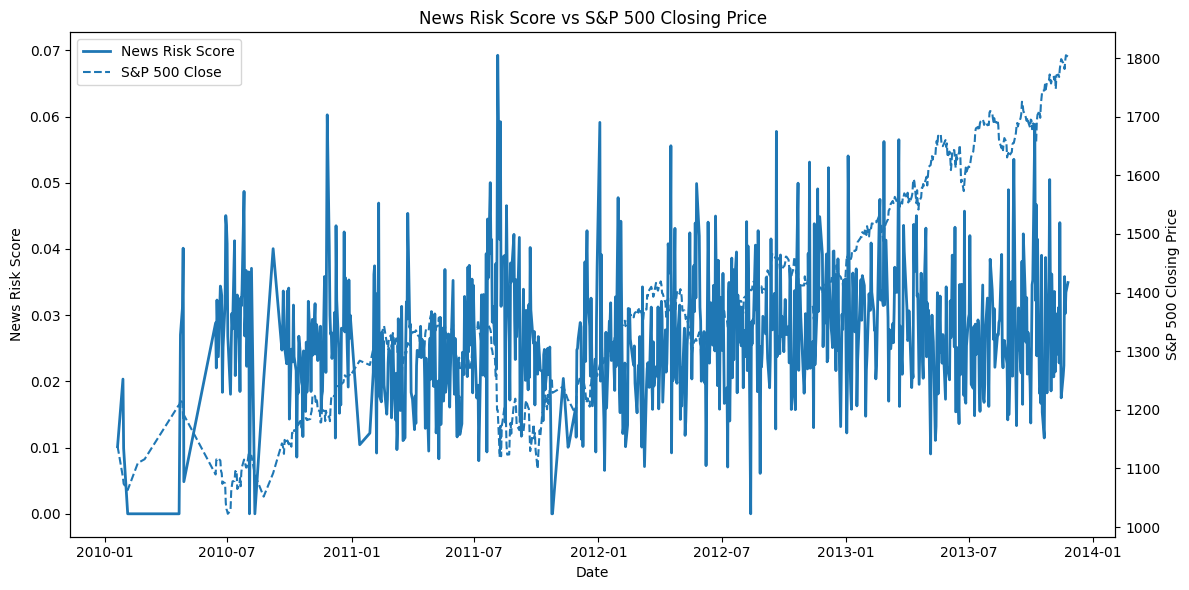

In [120]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Risk score (left Y-axis)
ax1.plot(
    merged['Date'],
    merged['risk_score'],
    label='News Risk Score',
    linewidth=2
)
ax1.set_xlabel('Date')
ax1.set_ylabel('News Risk Score')
ax1.tick_params(axis='y')

# S&P 500 Close (right Y-axis)
ax2 = ax1.twinx()
ax2.plot(
    merged['Date'],
    merged['Close'],
    linestyle='--',
    label='S&P 500 Close'
)
ax2.set_ylabel('S&P 500 Closing Price')
ax2.tick_params(axis='y')

# Title
plt.title('News Risk Score vs S&P 500 Closing Price')

# Legends (combined)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()


In [121]:
merged['risk_30d'] = merged['risk_score'].rolling(30).mean()
merged['sp500_return'] = merged['Close'].pct_change()

In [122]:
monthly = merged.set_index('Date').resample('M').agg({
    'risk_score': 'mean',
    'Close': 'last'
}).reset_index()


/tmp/ipython-input-1612956547.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = merged.set_index('Date').resample('M').agg({


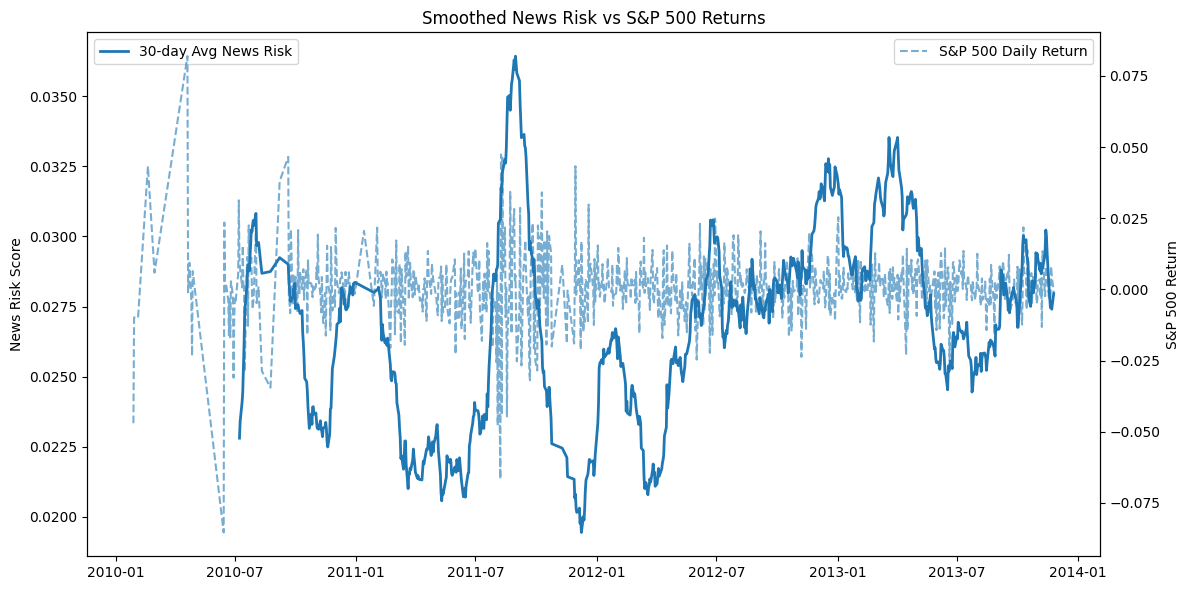

In [123]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    merged['Date'],
    merged['risk_30d'],
    label='30-day Avg News Risk',
    linewidth=2
)
ax1.set_ylabel('News Risk Score')

ax2 = ax1.twinx()
ax2.plot(
    merged['Date'],
    merged['sp500_return'],
    linestyle='--',
    alpha=0.6,
    label='S&P 500 Daily Return'
)
ax2.set_ylabel('S&P 500 Return')

ax1.set_title('Smoothed News Risk vs S&P 500 Returns')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


Periods with elevated news volume and negative sentiment was followed by increased market volatility indicating that news intensity may act as a leading indicator of uncertainty in financial markets.

Prior research has also documented that the frequency of inflation related keywords tends to peak during phases of monetary tightening, suggesting that news data can reflect broader macroeconomic regime shifts. However, this pattern could not be consistently verified within the limited time horizon of the present analysis.


# **7.Works Cited**

Ding,Xiao and Zhang,Yue. “Using Structured Events to Predict Stock Price Movement:
An Empirical Investigation.”,
https://emnlp2014.org/papers/pdf/EMNLP2014148.pdf. Accessed 25 Jan. 2026.

Hazarika,Ditiman et al."Sentiment Analysis on Twitter by Using TextBlob
for Natural Language Processing.",pp. 64-66,
https://annals-csis.org/proceedings/icrmat2020/drp/pdf/20.pdf.

Sun Yunchuan et al."Alternative data in finance and business:
emerging applications and theory analysis.",pp. 2-7,
https://link.springer.com/article/10.1186/s40854-024-00652-0